https://www.kaggle.com/datasets/shreenidhihipparagi/google-stock-prediction THIS IS THE DATASET THAT ARE GIVEN IN THE CODE

MODEL 1 TASK 2

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
from sklearn.metrics import mean_squared_error


In [6]:
df = pd.read_csv('GOOG.csv')  # Update path if needed
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

In [7]:
data = df[['close']].values


In [8]:
# 4. Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [9]:
# 5. Create training dataset (80% train, 20% test)
training_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:training_size]
test_data = scaled_data[training_size:]

In [10]:
# 6. Create sequences for LSTM
def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(time_step, len(dataset)):
        X.append(dataset[i - time_step:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

time_step = 60
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

In [19]:
# Reshape to fit LSTM input: [samples, time steps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [12]:
# 7. Build the LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

C:\Users\Rajguru\anaconda3\envs\stockenv\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
# 8. Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - loss: 0.0161
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.0012
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 6.2271e-04
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 5.9957e-04
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 5.2195e-04
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 4.3279e-04
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 4.4145e-04
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 4.4319e-04
Epoch 9/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 4.2893e-04
Epoch 10/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 4.4280e-04


In [14]:
# 9. Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)


30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [20]:
# 10. Inverse transform predictions
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_train_scaled = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler.inverse_transform(y_test.reshape(-1, 1))


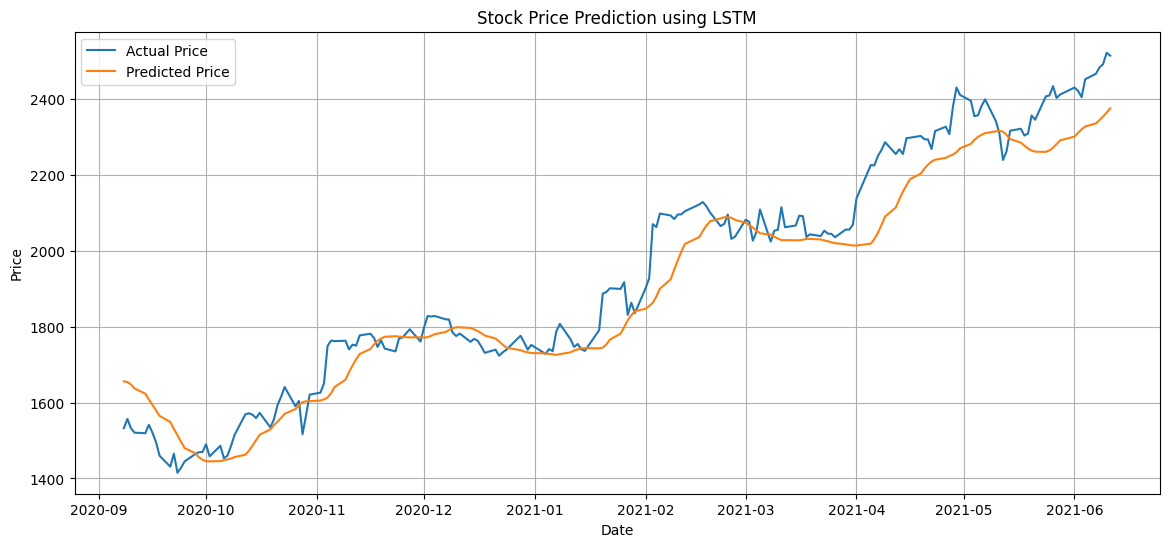

In [16]:
# 11. Plot the results
plt.figure(figsize=(14,6))
# Plot actual
plt.plot(df.index[training_size + time_step:], y_test_scaled, label='Actual Price')
# Plot predicted
plt.plot(df.index[training_size + time_step:], test_predict, label='Predicted Price')
plt.title("Stock Price Prediction using LSTM")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# 12. Print RMSE
rmse = np.sqrt(mean_squared_error(y_test_scaled, test_predict))
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Root Mean Squared Error (RMSE): 83.8377
